In [1]:
pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the data
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Check first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Check shape (rows and columns)
print("Rows and Columns:", df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (9994, 21)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
# Convert Order Date to proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year

print("Date column fixed successfully!")

Date column fixed successfully!


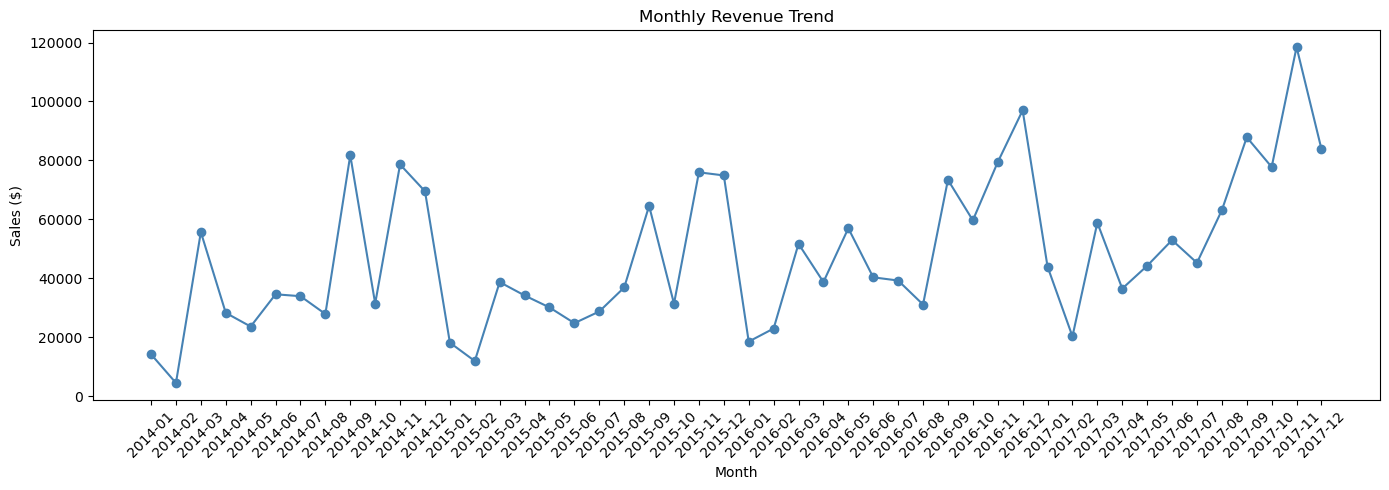

In [6]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_trend.png')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8860\1922723217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Sales', y='Product Name', palette='viridis')


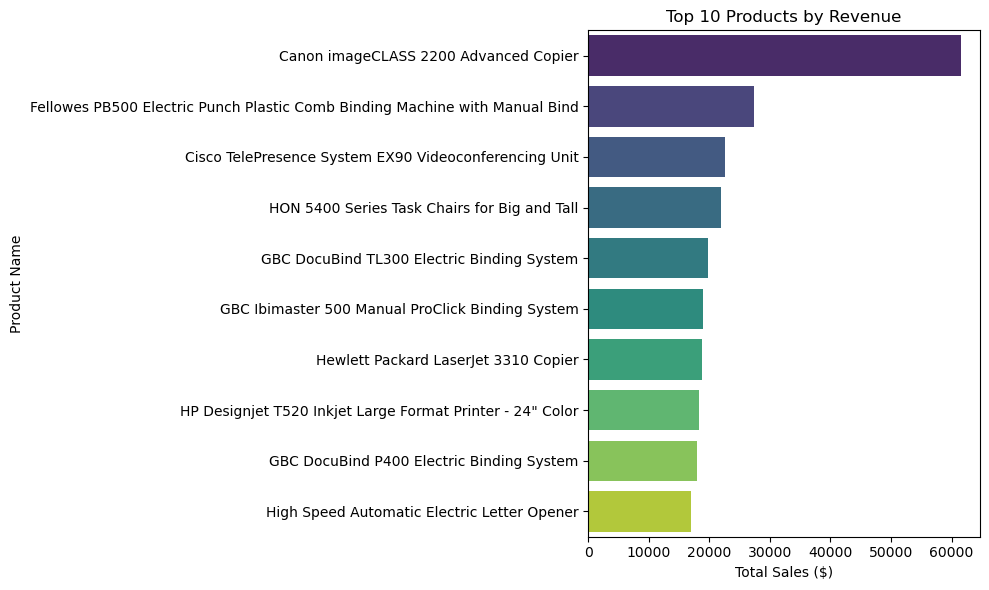

In [7]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

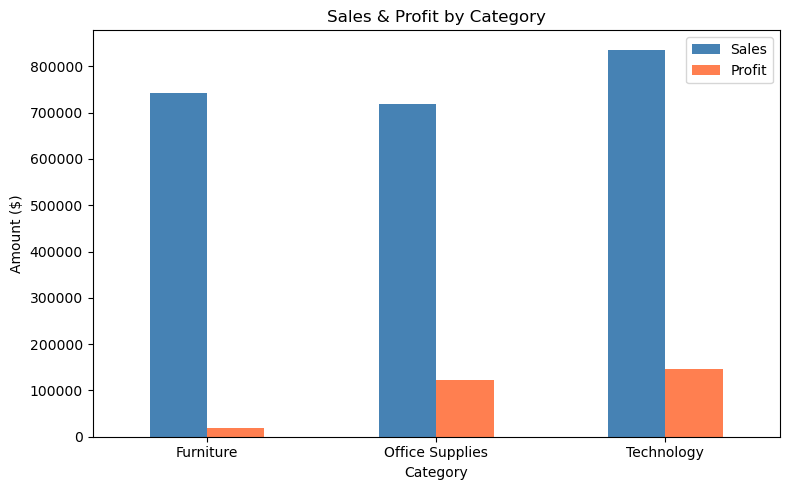

In [8]:
category_sales = df.groupby('Category')[['Sales','Profit']].sum().reset_index()

category_sales.plot(x='Category', kind='bar', figsize=(8,5),
                    title='Sales & Profit by Category',
                    color=['steelblue','coral'])
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8860\3817789843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')


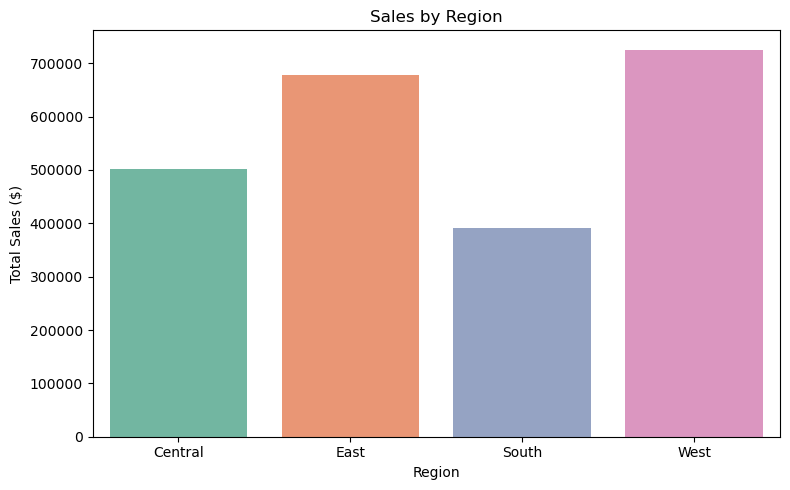

In [9]:
region_sales = df.groupby('Region')[['Sales','Profit']].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')
plt.title('Sales by Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()

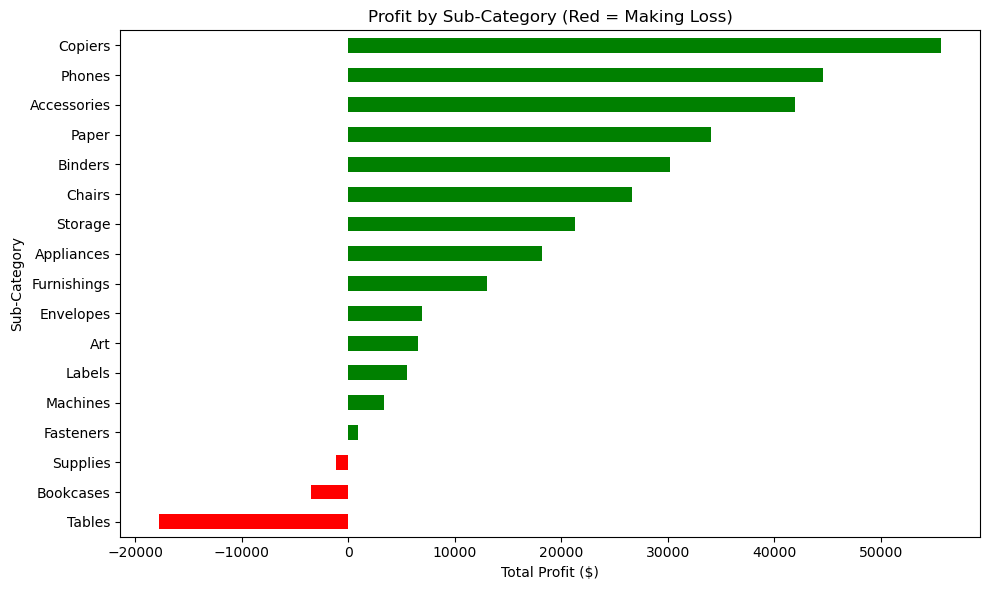

In [10]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'green' for x in subcategory_profit]

plt.figure(figsize=(10,6))
subcategory_profit.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category (Red = Making Loss)')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png')
plt.show()

In [11]:
print("===== KEY FINDINGS =====\n")

best_region = region_sales.loc[region_sales['Sales'].idxmax(), 'Region']
print(f"1. Best Performing Region: {best_region}")

best_category = category_sales.loc[category_sales['Sales'].idxmax(), 'Category']
print(f"2. Highest Selling Category: {best_category}")

best_product = top_products.iloc[0]['Product Name']
print(f"3. Top Product: {best_product}")

loss_cats = subcategory_profit[subcategory_profit < 0].index.tolist()
print(f"4. Loss-Making Sub-Categories: {loss_cats}")

total_revenue = df['Sales'].sum()
print(f"5. Total Revenue: ${total_revenue:,.2f}")

===== KEY FINDINGS =====

1. Best Performing Region: West
2. Highest Selling Category: Technology
3. Top Product: Canon imageCLASS 2200 Advanced Copier
4. Loss-Making Sub-Categories: ['Tables', 'Bookcases', 'Supplies']
5. Total Revenue: $2,297,200.86
